# No-EQI Baseline Model — Methodological Sensitivity Analysis

**Purpose:** Test how well the model performs WITHOUT any EPA environmental quality data — using only demographic features (Census/ACS) and other PLACES disease variables.

**Why this matters:** This represents what a state health department could achieve using publicly available CDC PLACES + Census data alone, without access to EPA's Environmental Quality Index. Comparing this baseline to the full model shows the *marginal contribution of the EQI environmental data*.

**Removed features (EPA environmental data):**
- Air: `ozone`, `pm25`, `nata_sum`
- Land: `pest`
- Built environment: `facilities_area`, `nindex_open`, `selfservice`
- Spatial context: `X_pop_dens`, `time2work`, `crime_index`, `food_ratio`, `education_area`

**Retained features (Census/ACS demographics + PLACES disease data):**
- Demographics: `poverty`, `bs_25yo`, `unemployment`, `rent_income_pct`, `RUCA_pri_cat`
- Other PLACES diseases & behaviors as predictors (same as main model)

**Targets:** STROKE, KIDNEY, CHD, CANCER (same as main model)

**Three-model comparison:**

| Model | EQI environmental? | Demographics? | PLACES disease data? |
|---|---|---|---|
| Full | ✓ | ✓ | ✓ |
| No-EQI (this notebook) | ✗ | ✓ | ✓ |
| EQI-only | ✓ | ✗ | ✗ |

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

cdc_epa_data = pd.read_csv(
    "/Users/virginiaberthy/UVA-MSDS/DS 5003 - Healthcare DS - SP '26/Group Project/FINAL MODEL & RUN/EQI_2011_2015_PLACES_2020_merged_copy.csv"
)
print(f"Loaded: {cdc_epa_data.shape[0]:,} rows, {cdc_epa_data.shape[1]} columns")

Loaded: 70,962 rows, 73 columns


In [12]:
# No-EQI feature set — Census/ACS demographics + PLACES disease data, NO environmental EPA data
no_eqi_features = [
    # Census/ACS demographics
    'poverty', 'bs_25yo', 'unemployment', 'rent_income_pct', 'RUCA_pri_cat',
    # Other PLACES diseases & behaviors used as predictors
    'PLACES_ACCESS2', 'PLACES_ARTHRITIS', 'PLACES_BINGE', 'PLACES_BPHIGH', 'PLACES_BPMED',
    'PLACES_CASTHMA', 'PLACES_CERVICAL', 'PLACES_CHECKUP',
    'PLACES_CHOLSCREEN', 'PLACES_COLON_SCREEN', 'PLACES_COPD', 'PLACES_COREM',
    'PLACES_COREW', 'PLACES_CSMOKING', 'PLACES_DENTAL', 'PLACES_DIABETES',
    'PLACES_HIGHCHOL', 'PLACES_LPA', 'PLACES_MAMMOUSE',
    'PLACES_MHLTH', 'PLACES_OBESITY', 'PLACES_PHLTH', 'PLACES_SLEEP',
    'PLACES_TEETHLOST',
]

targets = 'PLACES_STROKE'
id_cols = ['tract_fips', 'State', 'County', 'StateAbbr', 'CountyName']

cols_to_keep = no_eqi_features + [targets] + id_cols
cdc_epa_selected = cdc_epa_data[cols_to_keep]

# stratified 80/20 split by state — same random state as main model
cdc_epa_train, cdc_epa_test = train_test_split(
    cdc_epa_selected, test_size=0.2, random_state=5003,
    stratify=cdc_epa_selected['State']
)

feature_cols = no_eqi_features
num_cols = [c for c in feature_cols if cdc_epa_train[c].dtype in ['float64', 'int64']]

print(f"No-EQI features: {len(feature_cols)}")
print(f"Targets: {len(targets)}")
print(f"Train: {len(cdc_epa_train):,}  Test: {len(cdc_epa_test):,}")

No-EQI features: 29
Targets: 13
Train: 56,769  Test: 14,193


In [13]:
# same hyperparameter grid as main v2 model for fair comparison
xgb_params_v2 = {
    'n_estimators': [400, 500, 600, 800],
    'max_depth': [6, 7, 8, 10],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.75, 0.8, 0.85],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 2, 5],
    'gamma': [0, 0.1, 0.3],
}

results_no_eqi = []


X_train = cdc_epa_train[feature_cols].copy()
y_train = cdc_epa_train[targets]
X_test = cdc_epa_test[feature_cols].copy()
y_test = cdc_epa_test[targets]

imputer = SimpleImputer(strategy='median')
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

xgb_cv = RandomizedSearchCV(
    XGBRegressor(random_state=5003),
    xgb_params_v2, n_iter=100, cv=5, scoring='r2',
    random_state=5003, n_jobs=-1
)
xgb_cv.fit(X_train, y_train)

y_pred = xgb_cv.predict(X_test)
rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
r2 = round(r2_score(y_test, y_pred), 4)

print(f"{target.replace('PLACES_', ''):12s}  R²: {r2}  RMSE: {rmse}")

results_no_eqi.append({
    'Target': target.replace('PLACES_', ''),
    'R²_no_EQI': r2,
    'RMSE_no_EQI': rmse,
})

results_no_eqi_df = pd.DataFrame(results_no_eqi).sort_values('R²_no_EQI', ascending=False)
results_no_eqi_df

/opt/miniconda3/envs/ml-course/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


E             R²: 0.9911  RMSE: 0.1183


,Target,R²_no_EQI,RMSE_no_EQI
0,E,0.9911,0.1183


## Three-Model Comparison

Combining results from all three model variants:
- **Full:** All features (EQI + demographics + PLACES diseases)
- **No-EQI:** Demographics + PLACES diseases only (no EPA environmental data)
- **EQI-only:** Environmental + built environment only (no demographics, no PLACES diseases)

The key comparison: **Full vs No-EQI** = marginal contribution of the EPA environmental data.

In [14]:
# update with your actual final v2 numbers and EQI-only results
main_results = pd.DataFrame({
    'Target':    ['STROKE'],
    'R²_full':   [0.9965],
    'RMSE_full': [0.0747],
})

eqi_only_results = pd.DataFrame({
    'Target':         ['STROKE'],
    'R²_EQI_only':    [0.5563],
    'RMSE_EQI_only':  [0.8350],
})

comparison = main_results.merge(results_no_eqi_df, on='Target').merge(eqi_only_results, on='Target')

# marginal EQI contribution (Full vs No-EQI)
comparison['EQI_R²_gain'] = (comparison['R²_full'] - comparison['R²_no_EQI']).round(4)
comparison['EQI_RMSE_reduction'] = (comparison['RMSE_no_EQI'] - comparison['RMSE_full']).round(4)

comparison

,Target,R²_full,RMSE_full,R²_no_EQI,RMSE_no_EQI,R²_EQI_only,RMSE_EQI_only,EQI_R²_gain,EQI_RMSE_reduction


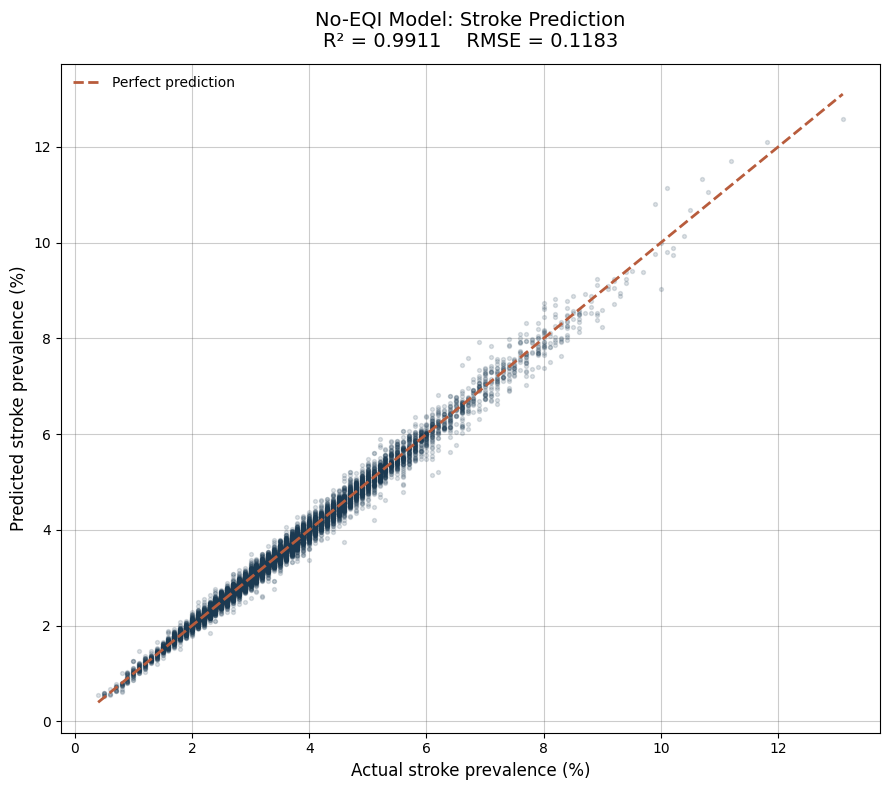

In [15]:
import matplotlib.pyplot as plt

BLUE = '#1B3A52'
ORANGE = '#B85C3C'
GREY = '#595959'

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(y_test, y_pred, alpha=0.15, s=8, color=BLUE)

lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], color=ORANGE, lw=2, ls='--', label='Perfect prediction')

ax.set_xlabel('Actual stroke prevalence (%)', fontsize=12)
ax.set_ylabel('Predicted stroke prevalence (%)', fontsize=12)
ax.set_title(f'No-EQI Model: Stroke Prediction\nR² = {r2}    RMSE = {rmse}', fontsize=14, pad=12)
ax.legend(frameon=False, loc='upper left')
ax.grid(True, alpha=0.3, color=GREY)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('no_eqi_stroke_scatter.png', dpi=150, bbox_inches='tight')
plt.show()